In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/POG570_small_mutations.txt', sep='\t')
df.head()

,chrom,pos,ref,alt,qual,af_tumour,tumour_ref_count,tumour_alt_count,tumour_total_count,library_name,patient_id,gene_id,transcript_id,aa_change,effect,impact,analysis_cohort,biopsy_cohort
0,1,23525266,G,A,23;0.97,0.130435,80,12,92,P02300,37862,HTR1D,ENST00000374619,NaN,upstream_gene_variant,MODIFIER,LUNG,Lymphatic System
1,2,134808718,G,A,49;0.94,0.226804,75,22,97,P01132,28132,NaN,NaN,NaN,intergenic_region,MODIFIER,LUNG,Respiratory System
2,2,170682950,G,A,80;0.941,0.410959,43,30,73,P01132,28132,METTL5,ENST00000260953,NaN,upstream_gene_variant,MODIFIER,LUNG,Respiratory System
3,2,76351513,T,A,34;0.9,0.166667,65,13,78,P01079,27723,NaN,NaN,NaN,intergenic_region,MODIFIER,LUNG,Brain
4,4,90849580,T,A,59;0.927,0.290909,78,32,110,P01079,27723,MMRN1,ENST00000394980,NaN,intron_variant,MODIFIER,LUNG,Brain


In [3]:
count_27723 = (df['patient_id'] == 27723).sum()
count_27723


np.int64(6134)

## Frequency of mutation counts in patients

In [4]:
patient_mutations = df['patient_id'].value_counts()
patient_mutations

patient_id
30809    457083
11698    416635
23674    264142
30489    246330
32395    243101
          ...  
31369       422
30253       396
28495       267
25979       147
25976        19
Name: count, Length: 570, dtype: int64

Text(0, 0.5, 'Overall Distribution of Mutation')

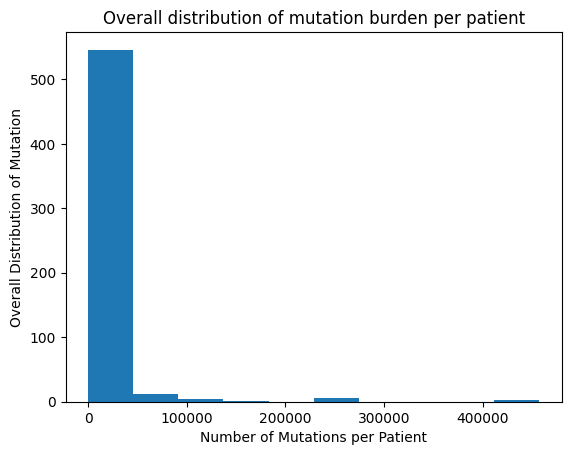

In [5]:
plt.hist(patient_mutations)
plt.title('Overall distribution of mutation burden per patient')
plt.xlabel("Number of Mutations per Patient")
plt.ylabel("Overall Distribution of Mutation")

In [6]:
patient_mutations_bin = patient_mutations.reset_index()
patient_mutations_bin["count_bin"] = pd.cut(patient_mutations_bin['count'],
                                           bins=[0, 10, 100, 1000, 10_000, 100_000, 1_000_000],
                                           labels=['0-10', '10-100', '100-1k', '1k-10k', '10k-100k', '100k-1M'])
patient_mutations_bin

,patient_id,count,count_bin
0,30809,457083,100k-1M
1,11698,416635,100k-1M
2,23674,264142,100k-1M
3,30489,246330,100k-1M
4,32395,243101,100k-1M
...,...,...,...
565,31369,422,100-1k
566,30253,396,100-1k
567,28495,267,100-1k
568,25979,147,100-1k


In [7]:
patient_mutations_bin

,patient_id,count,count_bin
0,30809,457083,100k-1M
1,11698,416635,100k-1M
2,23674,264142,100k-1M
3,30489,246330,100k-1M
4,32395,243101,100k-1M
...,...,...,...
565,31369,422,100-1k
566,30253,396,100-1k
567,28495,267,100-1k
568,25979,147,100-1k


In [8]:
patient_mutations_counts = patient_mutations_bin.groupby('count_bin').size().reset_index()
patient_mutations_counts.rename(columns={0: 'num_patients'}, inplace=True)
patient_mutations_counts

/var/folders/38/729z8yp171584gh7mkn2wgvr0000gn/T/ipykernel_4733/3620112263.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_mutations_counts = patient_mutations_bin.groupby('count_bin').size().reset_index()


,count_bin,num_patients
0,0-10,0
1,10-100,1
2,100-1k,14
3,1k-10k,375
4,10k-100k,168
5,100k-1M,12


<Axes: xlabel='count_bin', ylabel='num_patients'>

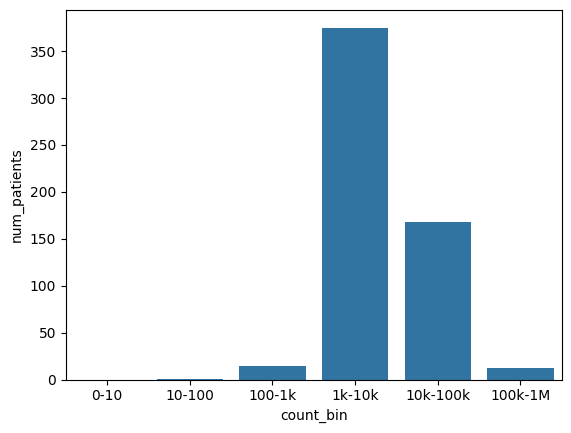

In [9]:
sns.barplot(
    data=patient_mutations_counts, 
    x='count_bin', 
    y='num_patients'
)

## Count number of patients with each cancer type

In [10]:
cancer_patient_id = df[["patient_id", "analysis_cohort"]]
print(cancer_patient_id.shape)
cancer_patient_id.drop_duplicates(inplace=True)
print(cancer_patient_id.shape)
cancer_patient_id.head()


(8142477, 2)
(570, 2)


/var/folders/38/729z8yp171584gh7mkn2wgvr0000gn/T/ipykernel_4733/1977781644.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cancer_patient_id.drop_duplicates(inplace=True)


,patient_id,analysis_cohort
0,37862,LUNG
1,28132,LUNG
3,27723,LUNG
7,30505,SECR
9,34117,BCC


In [11]:
cancer_patient_id_count = (
    cancer_patient_id
    .groupby("analysis_cohort")["patient_id"]
    .count()
)
cancer_patient_id_count
total_patients = cancer_patient_id_count.sum()
print(f"Total number of patients: {total_patients}")
cancer_patient_id_count


Total number of patients: 570


analysis_cohort
ACC          4
BCC          3
BLCA         1
BRCA       144
CERV         4
CHOL        14
CNS-PNS     19
COLO        87
ESCA        10
HCC          2
HNSC         7
KDNY         5
LUNG        67
LYMP        11
MISC        11
OV          28
PANC        42
PRAD         3
SARC        47
SECR        12
SKCM        13
STAD        11
THCA         4
THYM         4
UCEC        11
UVM          6
Name: patient_id, dtype: int64

In [12]:
patient_mutations_bin


,patient_id,count,count_bin
0,30809,457083,100k-1M
1,11698,416635,100k-1M
2,23674,264142,100k-1M
3,30489,246330,100k-1M
4,32395,243101,100k-1M
...,...,...,...
565,31369,422,100-1k
566,30253,396,100-1k
567,28495,267,100-1k
568,25979,147,100-1k


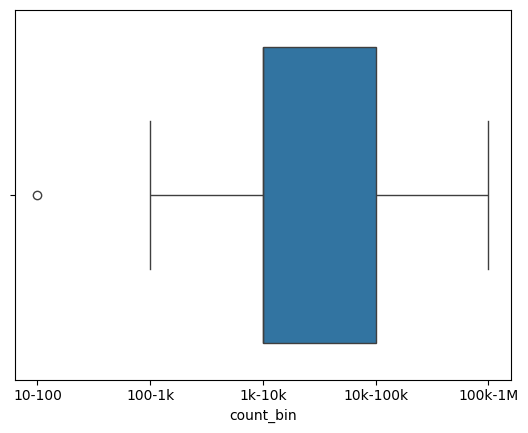

In [13]:
sns.boxplot(x = "count_bin",  
            data = patient_mutations_bin)
plt.show()

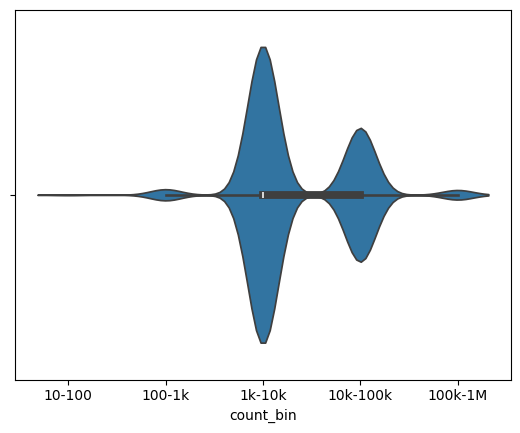

In [14]:
sns.violinplot(x = "count_bin",  
            data = patient_mutations_bin)
plt.show()

## Does the total number of mutations differ between cancer types?

In [15]:
# columns = patient_id, analysis_cohort (cancer type), mutation_count (for each patient)
# boxplot of mutation_count for each cancer type
# x-axis will have cancer type, y-axis will have count
# no need to plot log count, just the regular count


total_mutations = (
    df.groupby(["patient_id", "analysis_cohort"])
    .size()
    .reset_index(name="mutation_count")
)
total_mutations.sort_values(by="mutation_count", ascending=False, inplace=True)
total_mutations.head()


,patient_id,analysis_cohort,mutation_count
360,30809,SKCM,457083
2,11698,BCC,416635
90,23674,COLO,264142
342,30489,SKCM,246330
406,32395,HNSC,243101


Text(0, 0.5, 'Mutation Count (log scale)')

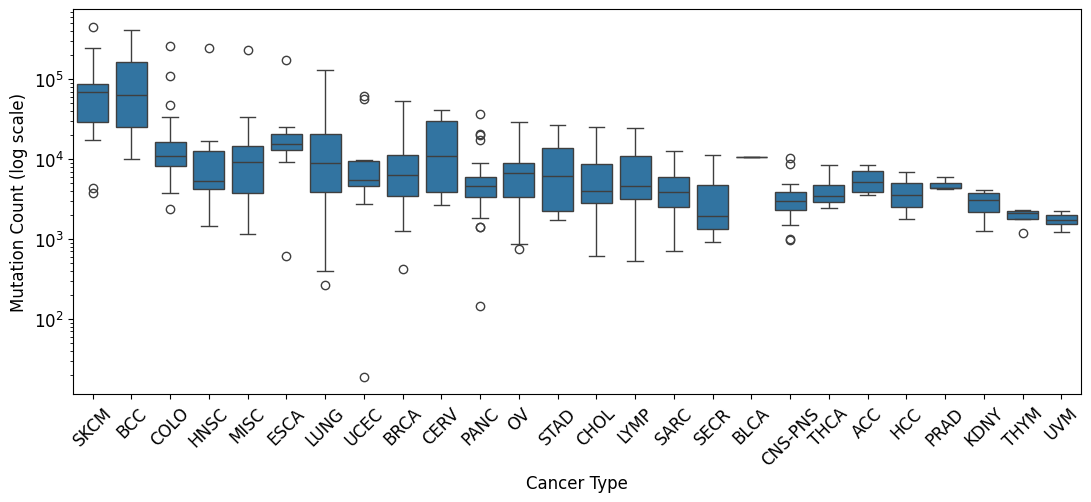

In [16]:
plt.figure(figsize=(13, 5))
sns.boxplot(x = "analysis_cohort", y = "mutation_count",
            data = total_mutations, log_scale=True)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Cancer Type", fontsize=12)
plt.ylabel("Mutation Count (log scale)", fontsize=12)

Text(0, 0.5, 'Mutation Count (log scale)')

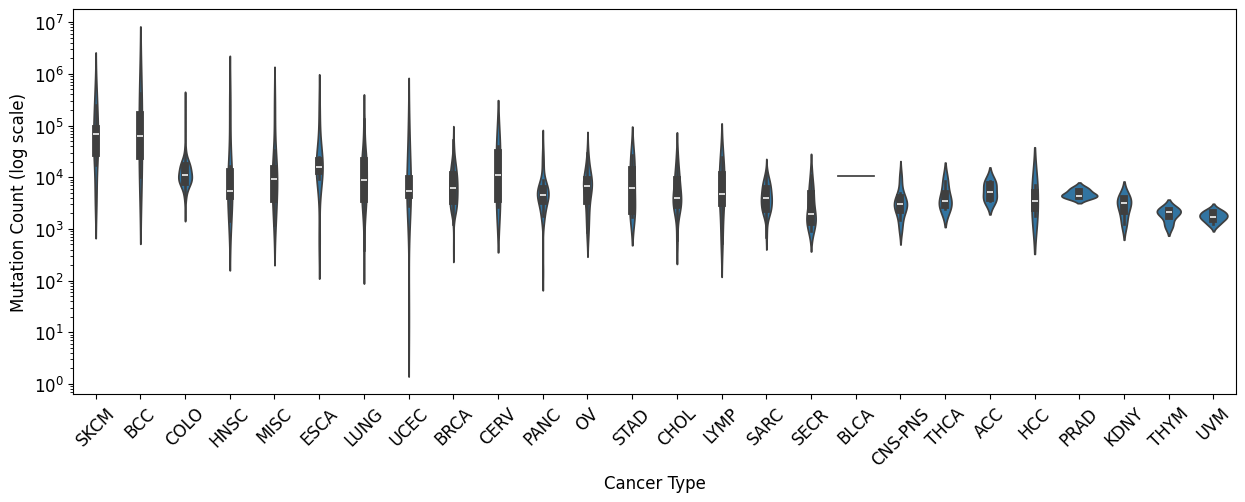

In [17]:
plt.figure(figsize=(15, 5))
sns.violinplot(x = "analysis_cohort", y = "mutation_count",
            data = total_mutations, log_scale=True)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Cancer Type", fontsize=12)
plt.ylabel("Mutation Count (log scale)", fontsize=12)